![tasks](../docs/tasks.png)


## XGBoostのモデル構築

In [1]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap
import optuna
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
x_train = pd.read_csv('../data/treated-data/task1/df_x_train.csv')
y_train = pd.read_csv('../data/treated-data/task1/df_y_train.csv')
x_test = pd.read_csv('../data/treated-data/task1/df_x_test.csv')
y_test = pd.read_csv('../data/treated-data/task1/df_y_test.csv')

In [4]:
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## 変数重要度

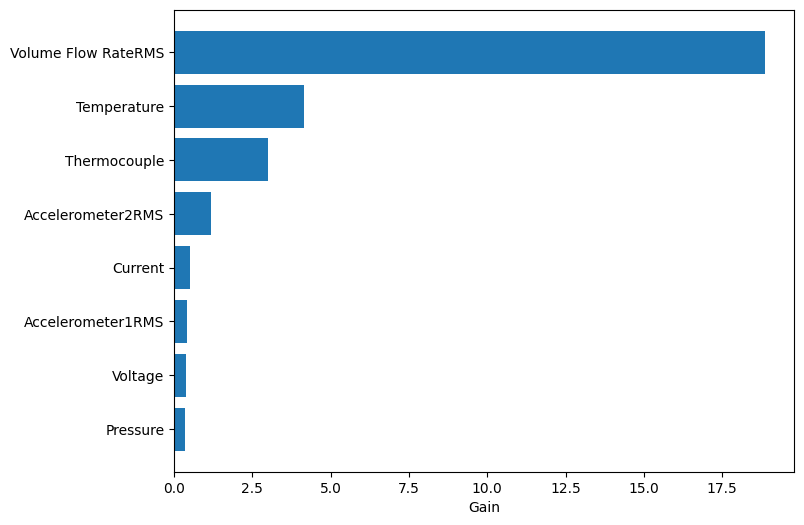

In [14]:
importance = xgb_model.get_booster().get_score(importance_type="gain")

imp_df = (
    pd.DataFrame(importance.items(), columns=["feature", "importance"])
      .sort_values("importance", ascending=False)
)

# プロット
plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Gain")
plt.show()

In [4]:
datetime_str = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f'../models/xgb_{datetime_str}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(xgb_model, f)
    print(f"モデルを {model_filename} に保存しました。")

モデルを ../models/xgb_20260106_182522.pkl に保存しました。


## SHAP

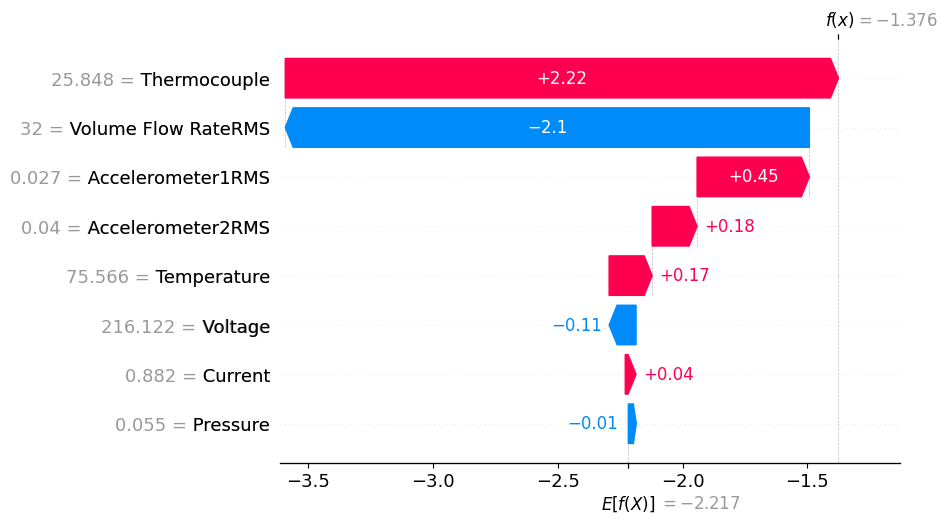

None

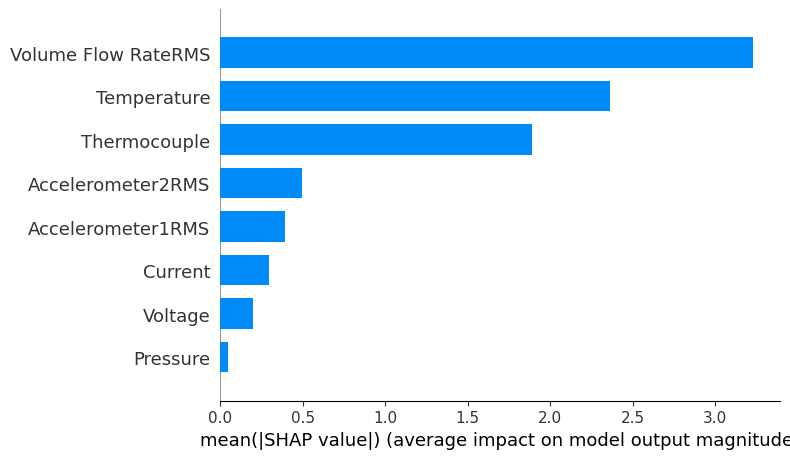

None

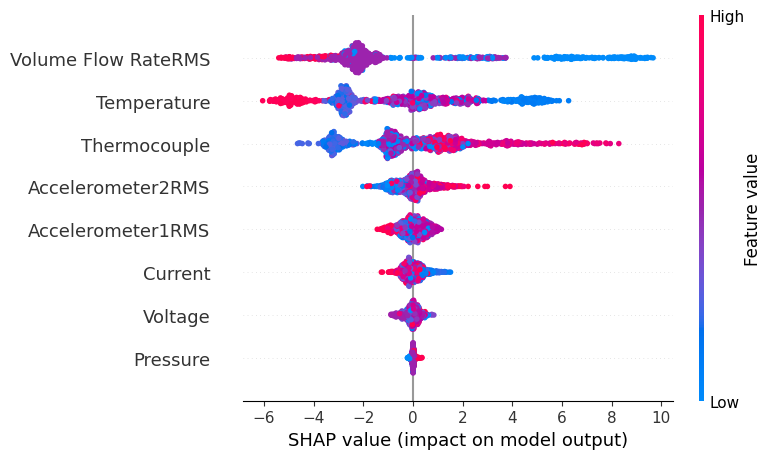

None

In [17]:
# SHAPによるモデル説明の構築
# Tree系のモデルの場合はTreeExplainerを利用する
explainer_B = shap.TreeExplainer(xgb_model, x_test)
shap_values_B = explainer_B(x_test)

# Waterfallモデルによる可視化
display(shap.plots.waterfall(shap_values_B[0]))

shap.initjs()
display(shap.plots.force(shap_values_B[0]))

display(shap.summary_plot(shap_values_B, plot_type='bar'))

display(shap.summary_plot(shap_values_B))